Problem 1: Z-Score Method (Normal Data)

In [14]:
import numpy as np
df = np.array([18, 19, 20, 20, 21, 21, 22, 22, 23, 24, 25, 26, 27, 28, 30, 32, 35, 40, 45, 70])
print(np.mean(df))
print(np.std(df))
z_scores = (df - np.mean(df))/(np.std(df))
print(z_scores)
outliers = df[(np.abs(z_scores))>3]
print(outliers)
df = df[(np.abs(z_scores))<=3]
df


28.4
11.825396399275586
[-0.87946312 -0.79489936 -0.7103356  -0.7103356  -0.62577183 -0.62577183
 -0.54120807 -0.54120807 -0.45664431 -0.37208055 -0.28751679 -0.20295303
 -0.11838927 -0.0338255   0.13530202  0.30442954  0.55812083  0.98093963
  1.40375844  3.51785248]
[70]


array([18, 19, 20, 20, 21, 21, 22, 22, 23, 24, 25, 26, 27, 28, 30, 32, 35,
       40, 45])

Problem 2: IQR Method (Skewed Data)

In [21]:
import pandas as pd
df = np.array([25, 28, 30, 32, 32, 33, 35, 35, 36, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 120, 150, 200, 250, 500])
Q1 = np.quantile(df,0.25)
print(Q1)
Q3 = np.quantile(df,0.75)
print(Q3)

IQR = Q3 - Q1
print(IQR)

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
print(lower_bound)
print(upper_bound)

outliers = df[(df < lower_bound) | (df > upper_bound)]
print(outliers)

df_clipped = df.clip(lower_bound, upper_bound)
print(df_clipped)

print(min(df_clipped))
print(max(df_clipped))

35.0
70.0
35.0
-17.5
122.5
[150 200 250 500]
[ 25.   28.   30.   32.   32.   33.   35.   35.   36.   38.   40.   42.
  45.   48.   50.   55.   60.   65.   70.   80.  120.  122.5 122.5 122.5
 122.5]
25.0
122.5


Problem 3: Choose the Right Method

<Axes: ylabel='Count'>

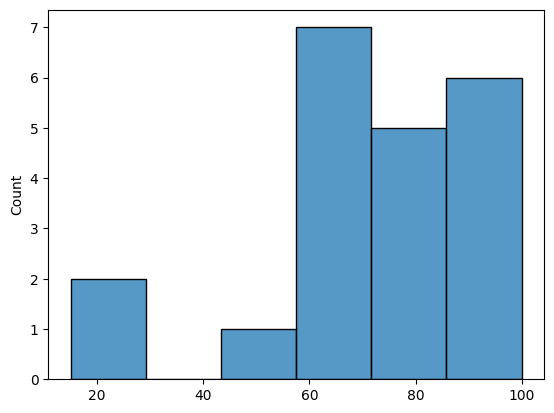

In [22]:
exam_scores = np.array([55, 58, 60, 62, 65, 65, 68, 70, 72, 75, 78, 80, 85, 90, 95, 98, 100, 100, 100, 15, 20])
house_prices = np.array([30, 32, 35, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 300, 400, 500, 800, 1000, 1200])

import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(exam_scores)


It is skewed. I will choose IQR method, because for skewed data, it works better


<Axes: ylabel='Count'>

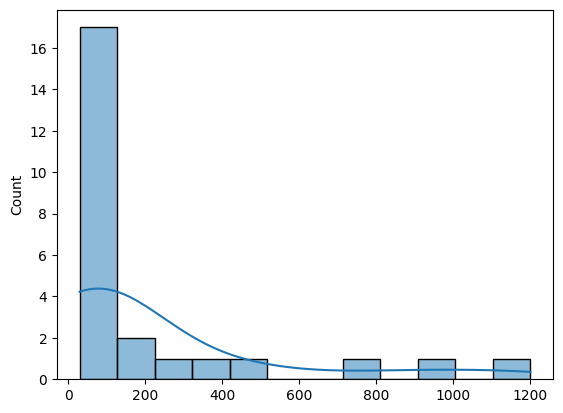

In [23]:
sns.histplot(house_prices, kde=True)

use iqr as skewed

In [24]:
Q1 = np.quantile(exam_scores, 0.25)
Q3 = np.quantile(exam_scores, 0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
outliers = exam_scores[(exam_scores < lower_bound) | (exam_scores > upper_bound)]
print(outliers)

[15]


Problem 4: Winsorization (Percentile Method)

In [25]:
df = np.array([1, 2, 3, 4, 4, 5, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 1, 2, 10, 10, 10, 0.5, 9.5])
x = 5
x= x/100
min_range = np.quantile(df, x)
max_range = np.quantile(df, 1-x)

print(min_range)
print(max_range)

df_clipped = df.clip(min_range, max_range)
print(df_clipped)

print(min(df_clipped))
print(max(df_clipped))



1.0
10.0
[ 1.   2.   3.   4.   4.   5.   5.   5.   6.   6.   7.   7.   8.   8.
  9.   9.  10.  10.   1.   2.  10.  10.  10.   1.   9.5]
1.0
10.0


Problem 5: Mixed Methods – Compare Z-Score & IQR on Same Data

<Axes: ylabel='Count'>

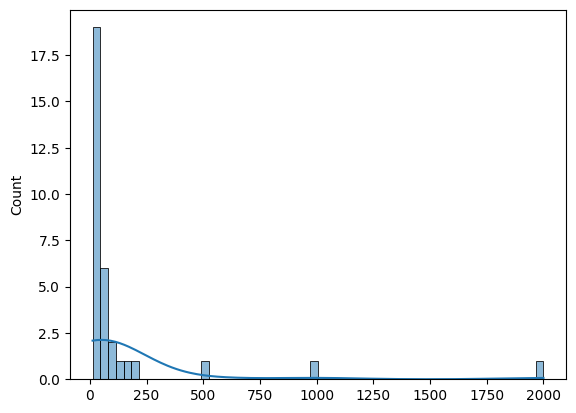

In [26]:
df = np.array([12, 15, 18, 20, 22, 22, 23, 24, 25, 25, 26, 27, 28, 30, 32, 35, 38, 40, 45, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 500, 1000, 2000])
sns.histplot(df, kde=True)

In [27]:
# skewed data
mean = df.mean()
z_score = (df-mean)/df.std()
outliers = df[np.abs(z_score)>3]
print(len(outliers))
print(outliers)


1
[2000]


In [28]:
Q1 = np.quantile(df, 0.25)
Q3 = np.quantile(df, 0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df < lower_bound) | (df > upper_bound)]
print(len(outliers))
print(outliers)

4
[ 200  500 1000 2000]


In [29]:
# IQR method is better for skewed data. Z-score method is better for normally distributed data.

Problem 6: Real-World Scenario – Employee Bonus

In [39]:
from statistics import mode
df = np.array([5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 10, 10, 10, 11, 12, 13, 15, 18, 20, 25, 30, 35, 40, 50, 60, 80, 100, 120, 150, 200, 300])
print(np.mean(df))
print(np.median(df))
print(mode(df))

Q1 = np.quantile(df, 0.25)
Q3 = np.quantile(df, 0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
outliers = df[(df<lower_bound)|(df>upper_bound)]
print(outliers)

x = 3/100
min_range = np.quantile(df,x)
max_range = np.quantile(df, 1-x)
df_clipped = df.clip(min_range, max_range)
print(df_clipped)

print(min(df_clipped))
print(max(df_clipped))

print(df_clipped.mean())


42.24242424242424
12.0
7
[100 120 150 200 300]
[  5.   5.   6.   6.   7.   7.   7.   8.   8.   8.   9.   9.  10.  10.
  10.  11.  12.  13.  15.  18.  20.  25.  30.  35.  40.  50.  60.  80.
 100. 120. 150. 200. 204.]
5.0
203.99999999999991
39.333333333333336
